<a href="https://colab.research.google.com/github/VivekChaurasiya95/DecodeLabs-Internship/blob/main/Decodelabs_Project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DecodeLabs Project 2

### Install Libraries

In [3]:
!pip install -q imbalanced-learn

### Import Libraries

In [4]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from imblearn.pipeline import Pipeline as ImbPipeline

from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

import joblib

### Load Dataset

In [5]:
from google.colab import files

uploaded = files.upload()

Saving credit_card_fraud_10k.csv to credit_card_fraud_10k.csv


In [6]:
df = pd.read_csv("credit_card_fraud_10k.csv")

df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


#### Dataset Shape



In [7]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 10000
Columns : 10


#### Column Names

In [8]:
df.columns

Index(['transaction_id', 'amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud'],
      dtype='object')

#### Data Types

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


#### Statistical Summary

In [10]:
df.describe()

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,175.949849,11.593300,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,2886.89568,175.392827,6.922708,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,1.00000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
25%,2500.75000,50.905000,6.000000,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000
50%,5000.50000,122.095000,12.000000,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000
75%,7500.25000,242.480000,18.000000,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000
max,10000.00000,1471.040000,23.000000,1.000000,1.000000,99.000000,9.000000,69.000000,1.000000


#### Missing Values

In [11]:
df.isnull().sum()

,0
transaction_id,0
amount,0
transaction_hour,0
merchant_category,0
foreign_transaction,0
location_mismatch,0
device_trust_score,0
velocity_last_24h,0
cardholder_age,0
is_fraud,0


#### Duplicate Rows

In [12]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


### Exploratory Data Analysis

#### Target Distribution

In [13]:
df["is_fraud"].value_counts()

,count
is_fraud,
0,9849
1,151


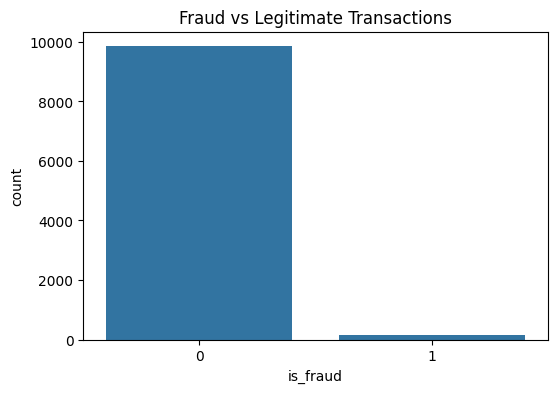

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="is_fraud"
)

plt.title("Fraud vs Legitimate Transactions")

plt.show()

#### Percentage

In [15]:
fraud_percent = df["is_fraud"].value_counts(normalize=True)*100

print(fraud_percent)

is_fraud
0    98.49
1     1.51
Name: proportion, dtype: float64


#### Pie Chart

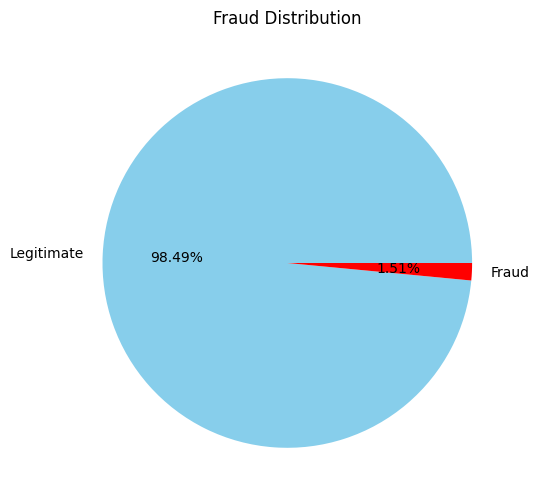

In [16]:
plt.figure(figsize=(6,6))

plt.pie(
    fraud_percent,
    labels=["Legitimate","Fraud"],
    autopct="%1.2f%%",
    colors=["skyblue","red"]
)

plt.title("Fraud Distribution")

plt.show()

### Feature Distributions

#### Transaction Amount

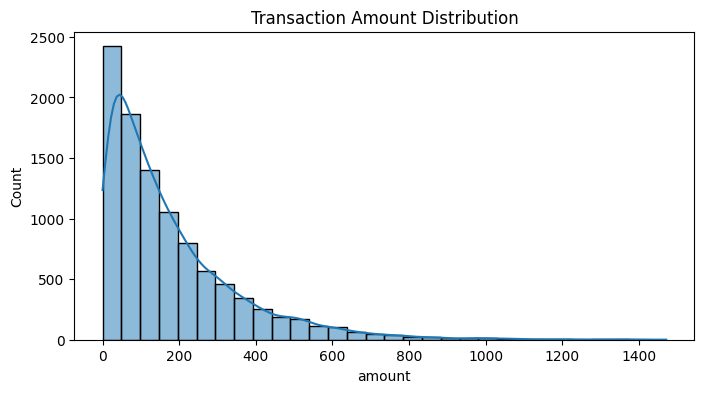

In [17]:
plt.figure(figsize=(8,4))

sns.histplot(
    df["amount"],
    bins=30,
    kde=True
)

plt.title("Transaction Amount Distribution")

plt.show()

#### Transaction Hour

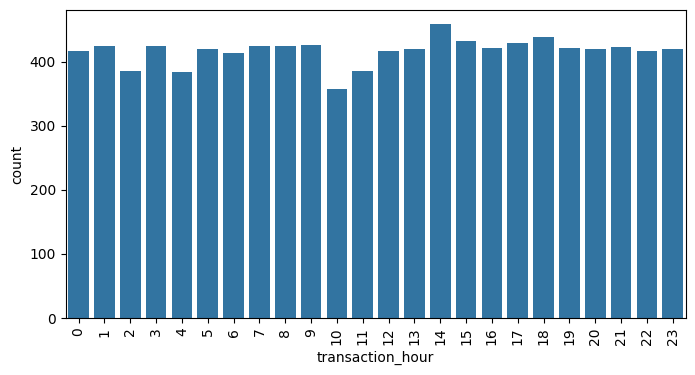

In [18]:
plt.figure(figsize=(8,4))

sns.countplot(
    x=df["transaction_hour"]
)

plt.xticks(rotation=90)

plt.show()

#### Merchant Category

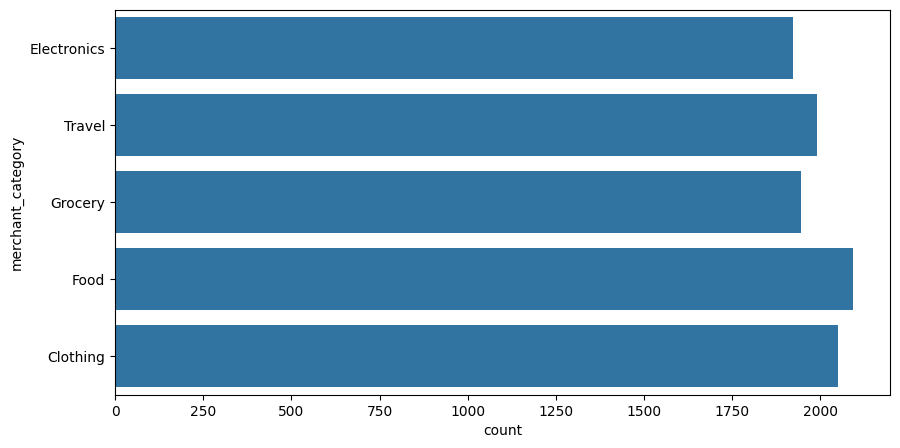

In [19]:
plt.figure(figsize=(10,5))

sns.countplot(
    y=df["merchant_category"]
)

plt.show()

#### Fraud by Merchant Category

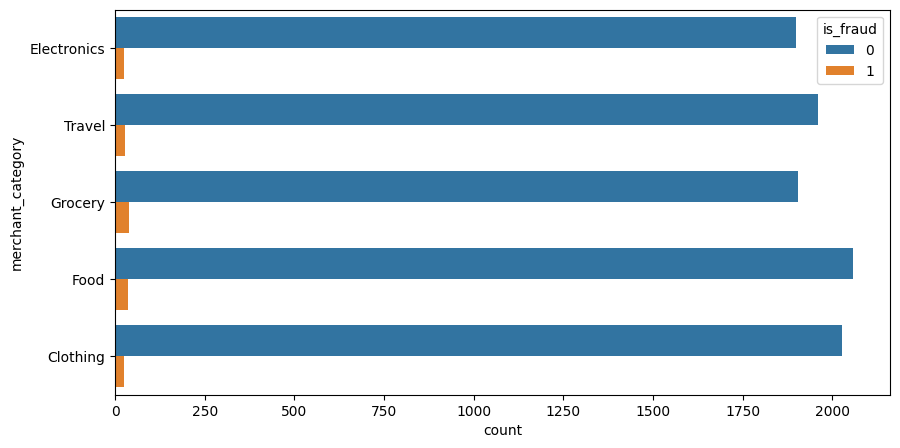

In [20]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    y="merchant_category",
    hue="is_fraud"
)

plt.show()

#### Foreign Transaction

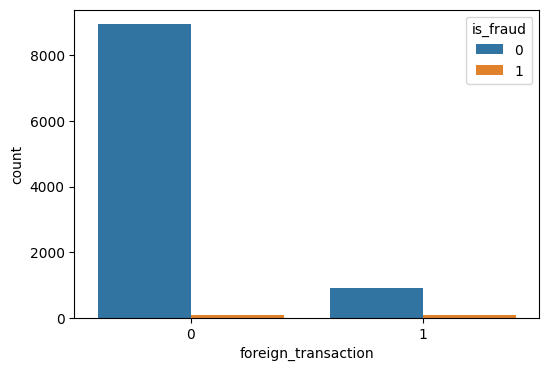

In [21]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="foreign_transaction",
    hue="is_fraud"
)

plt.show()

#### Location Mismatch

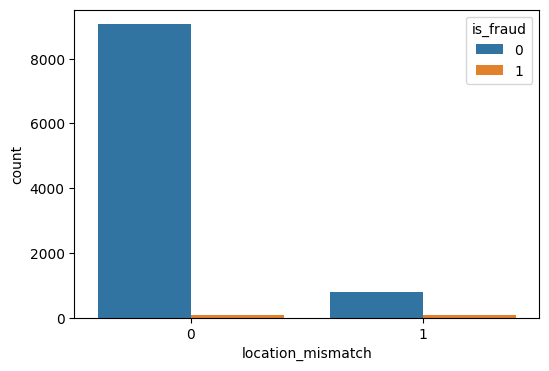

In [22]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="location_mismatch",
    hue="is_fraud"
)

plt.show()

#### Correlation Heatmap

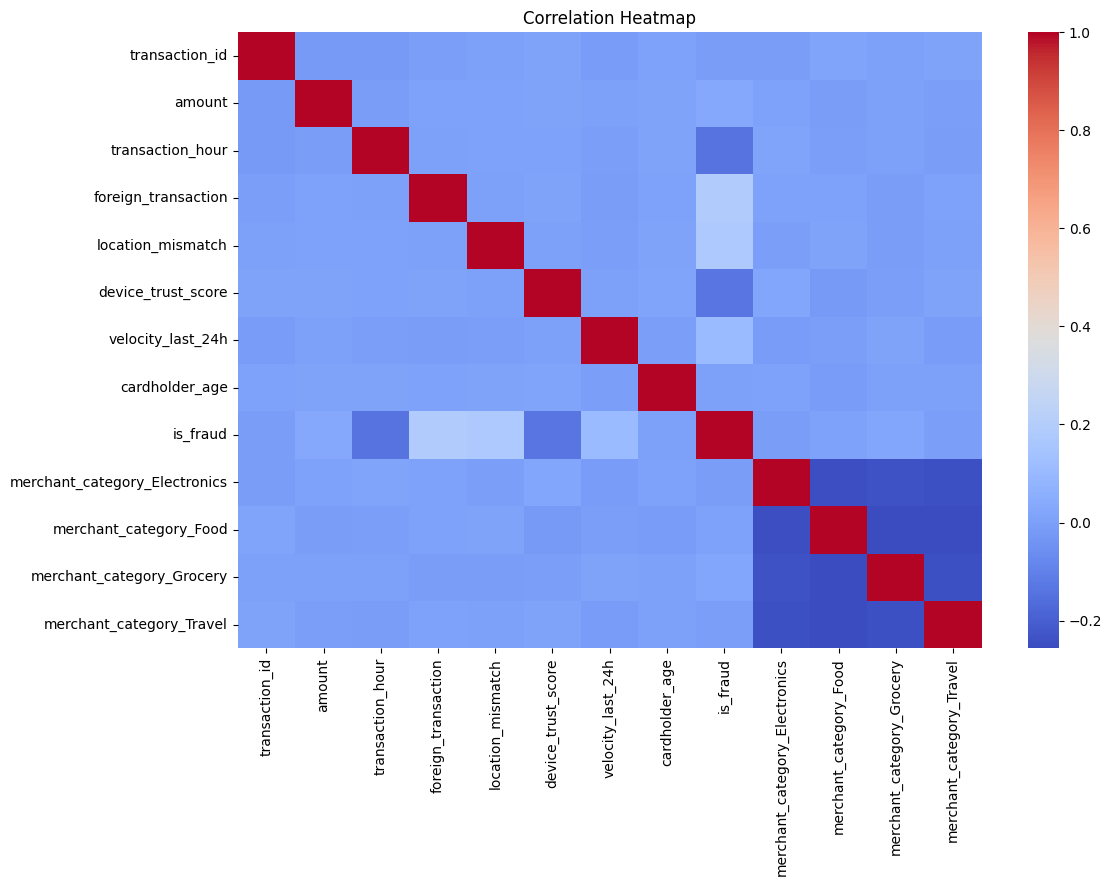

In [23]:
temp = df.copy()

temp = pd.get_dummies(temp, drop_first=True)

plt.figure(figsize=(12,8))

sns.heatmap(
    temp.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

### Data Preprocessing

#### Remove Transaction ID

In [24]:
df = df.drop("transaction_id", axis=1)

#### Separate Features and Target

In [25]:
X = df.drop("is_fraud", axis=1)

y = df["is_fraud"]

#### Identify Numerical Columns

In [26]:
numeric_features = X.select_dtypes(include=np.number).columns.tolist()

numeric_features

['amount',
 'transaction_hour',
 'foreign_transaction',
 'location_mismatch',
 'device_trust_score',
 'velocity_last_24h',
 'cardholder_age']

#### Identify Categorical Columns

In [27]:
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

categorical_features

['merchant_category']

#### Train Test Split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(8000, 8)
(2000, 8)


### Feature Engineering & Preprocessing Pipeline

#### Create the Preprocessor

In [29]:
# Numerical features
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns

# Categorical features
categorical_features = X.select_dtypes(include=['object']).columns

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

# Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

Numerical Features:
Index(['amount', 'transaction_hour', 'foreign_transaction',
       'location_mismatch', 'device_trust_score', 'velocity_last_24h',
       'cardholder_age'],
      dtype='object')

Categorical Features:
Index(['merchant_category'], dtype='object')


#### Display Features

In [30]:
print("Number of Numerical Features :", len(numeric_features))
print("Number of Categorical Features :", len(categorical_features))

Number of Numerical Features : 7
Number of Categorical Features : 1


### Handling Imbalanced Data (SMOTE)

#### Check Original Class Distribution

Before SMOTE

is_fraud
0    7879
1     121
Name: count, dtype: int64


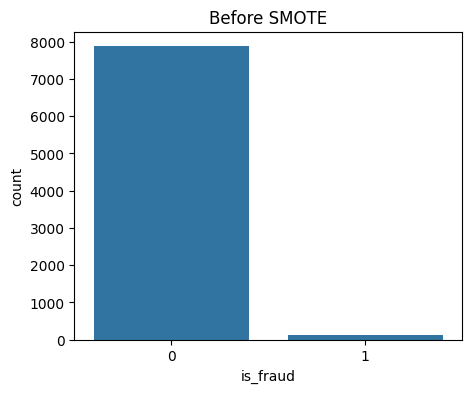

In [31]:
print("Before SMOTE\n")
print(y_train.value_counts())

plt.figure(figsize=(5,4))
sns.countplot(x=y_train)
plt.title("Before SMOTE")
plt.show()

#### Apply Preprocessing

In [32]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

#### Apply SMOTE

In [33]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

#### Check Distribution After SMOTE

After SMOTE

is_fraud
0    7879
1    7879
Name: count, dtype: int64


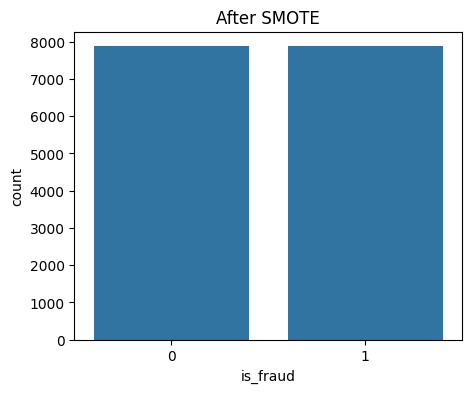

In [34]:
print("After SMOTE\n")
print(pd.Series(y_train_smote).value_counts())

plt.figure(figsize=(5,4))
sns.countplot(x=pd.Series(y_train_smote))
plt.title("After SMOTE")
plt.show()

### Logistic Regression

#### Train Logistic Regression

In [35]:
log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_model.fit(
    X_train_smote,
    y_train_smote
)

LogisticRegression(max_iter=1000, random_state=42)

#### Prediction

In [36]:
log_pred = log_model.predict(X_test_processed)

log_prob = log_model.predict_proba(X_test_processed)[:,1]

#### Accuracy

In [37]:
print("Accuracy :", accuracy_score(y_test, log_pred))

Accuracy : 0.9635


#### Precision

In [38]:
print("Precision :", precision_score(y_test, log_pred))

Precision : 0.2871287128712871


#### Recall

In [39]:
print("Recall :", recall_score(y_test, log_pred))

Recall : 0.9666666666666667


#### F1 Score

In [40]:
print("F1 Score :", f1_score(y_test, log_pred))

F1 Score : 0.44274809160305345


#### ROC AUC


In [41]:
print("ROC AUC :", roc_auc_score(y_test, log_prob))

ROC AUC : 0.9932994923857867


#### Classification Report

In [42]:
print(classification_report(
    y_test,
    log_pred
))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98      1970
           1       0.29      0.97      0.44        30

    accuracy                           0.96      2000
   macro avg       0.64      0.97      0.71      2000
weighted avg       0.99      0.96      0.97      2000



#### Confusion Matrix

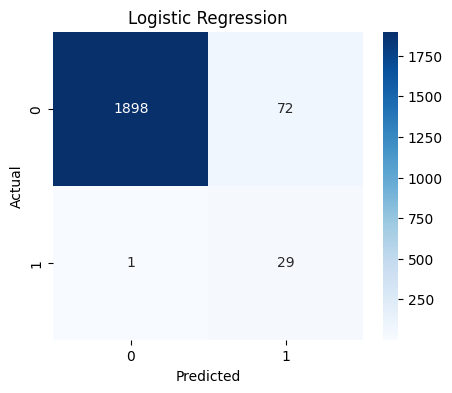

In [43]:
cm = confusion_matrix(
    y_test,
    log_pred
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression")

plt.show()

### Random Forest

#### Train Random Forest

In [44]:
rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(
    X_train_smote,
    y_train_smote
)

RandomForestClassifier(random_state=42)

#### Prediction

In [45]:
rf_pred = rf_model.predict(
    X_test_processed
)

rf_prob = rf_model.predict_proba(
    X_test_processed
)[:,1]

#### Accuracy

In [46]:
print("Accuracy :", accuracy_score(
    y_test,
    rf_pred
))

Accuracy : 0.995


#### Precision

In [47]:
print("Precision :", precision_score(
    y_test,
    rf_pred
))

Precision : 1.0


#### Recall

In [48]:
print("Recall :", recall_score(
    y_test,
    rf_pred
))

Recall : 0.6666666666666666


#### F1 Score

In [49]:
print("F1 Score :", f1_score(
    y_test,
    rf_pred
))

F1 Score : 0.8


#### ROC AUC

In [50]:
print("ROC AUC :", roc_auc_score(
    y_test,
    rf_prob
))

ROC AUC : 0.9987986463620981


#### Classification Report

In [51]:
print(classification_report(
    y_test,
    rf_pred
))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1970
           1       1.00      0.67      0.80        30

    accuracy                           0.99      2000
   macro avg       1.00      0.83      0.90      2000
weighted avg       1.00      0.99      0.99      2000



#### Confusion Matrix

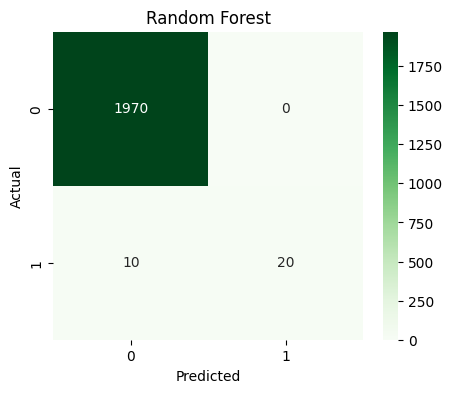

In [52]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Random Forest")

plt.show()

### Hyperparameter Tuning using GridSearchCV

#### Parameter Grid

In [53]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

#### Grid Search

In [55]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_smote, y_train_smote)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, None], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='f1', verbose=1)

#### Best Parameters

In [58]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


#### Best Score

In [59]:
print("Best F1 Score:")
print(grid_search.best_score_)

Best F1 Score:
0.9994925063792


#### Best Model

In [60]:
best_model = grid_search.best_estimator_

#### Prediction

In [61]:
best_pred = best_model.predict(X_test_processed)

best_prob = best_model.predict_proba(
    X_test_processed
)[:,1]

#### Evaluation

In [62]:
print("Accuracy :", accuracy_score(y_test, best_pred))

print("Precision :", precision_score(y_test, best_pred))

print("Recall :", recall_score(y_test, best_pred))

print("F1 Score :", f1_score(y_test, best_pred))

print("ROC AUC :", roc_auc_score(y_test, best_prob))

Accuracy : 0.994
Precision : 0.875
Recall : 0.7
F1 Score : 0.7777777777777778
ROC AUC : 0.9985786802030457


#### Classification Report

In [63]:
print(classification_report(
    y_test,
    best_pred
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       0.88      0.70      0.78        30

    accuracy                           0.99      2000
   macro avg       0.94      0.85      0.89      2000
weighted avg       0.99      0.99      0.99      2000



#### Confusion Matrix

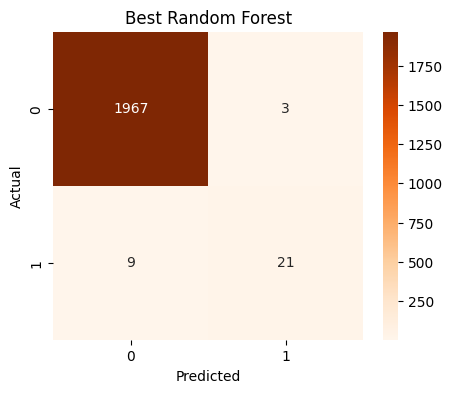

In [64]:
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Best Random Forest")

plt.show()

### ROC Curve

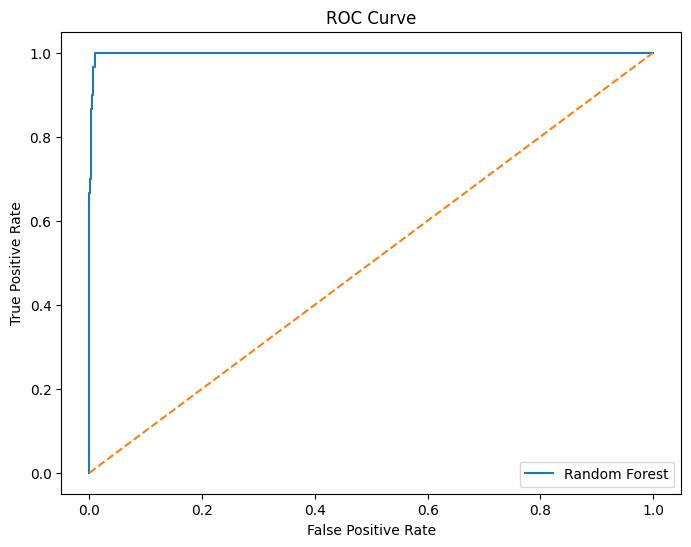

In [65]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    best_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label="Random Forest"
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

### Precision Recall Curve

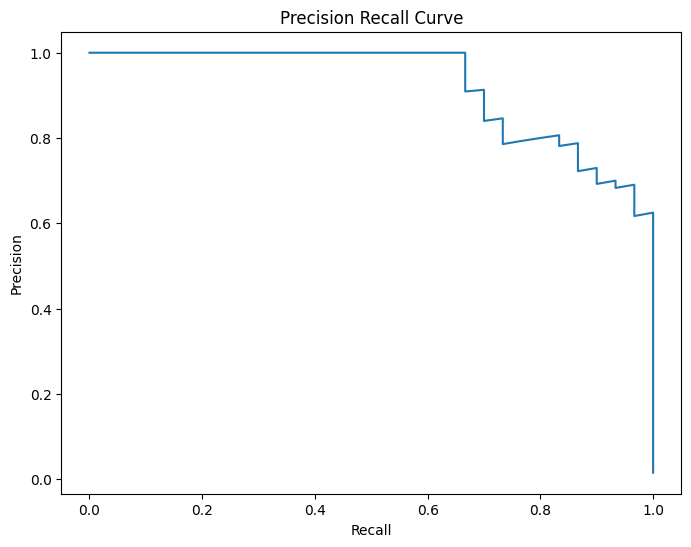

In [66]:
precision, recall, thresholds = precision_recall_curve(
    y_test,
    best_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.show()

### Feature Importance

In [67]:
encoded_features = preprocessor.named_transformers_[
    'cat'
].get_feature_names_out(
    categorical_features
)

feature_names = np.concatenate(
    [numeric_features, encoded_features]
)

In [68]:
importance = best_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
1,transaction_hour,0.283004
4,device_trust_score,0.221606
5,velocity_last_24h,0.135406
2,foreign_transaction,0.131994
3,location_mismatch,0.107752
8,merchant_category_Electronics,0.023422
0,amount,0.021939
11,merchant_category_Travel,0.017057
9,merchant_category_Food,0.016259
10,merchant_category_Grocery,0.016064


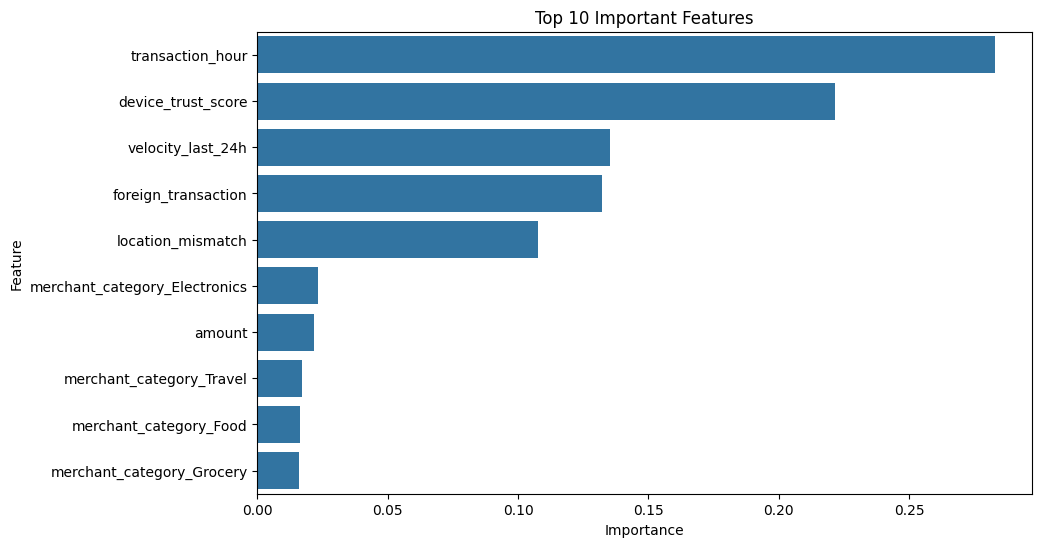

In [69]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.show()

### Model Comparison

In [70]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest",
        "Tuned Random Forest"
    ],

    "Accuracy":[

        accuracy_score(y_test, log_pred),

        accuracy_score(y_test, rf_pred),

        accuracy_score(y_test, best_pred)

    ],

    "Precision":[

        precision_score(y_test, log_pred),

        precision_score(y_test, rf_pred),

        precision_score(y_test, best_pred)

    ],

    "Recall":[

        recall_score(y_test, log_pred),

        recall_score(y_test, rf_pred),

        recall_score(y_test, best_pred)

    ],

    "F1 Score":[

        f1_score(y_test, log_pred),

        f1_score(y_test, rf_pred),

        f1_score(y_test, best_pred)

    ],

    "ROC AUC":[

        roc_auc_score(y_test, log_prob),

        roc_auc_score(y_test, rf_prob),

        roc_auc_score(y_test, best_prob)

    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.9635,0.287129,0.966667,0.442748,0.993299
1,Random Forest,0.9950,1.000000,0.666667,0.800000,0.998799
2,Tuned Random Forest,0.9940,0.875000,0.700000,0.777778,0.998579


In [71]:
comparison = comparison.sort_values(
    by="F1 Score",
    ascending=False
)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
1,Random Forest,0.9950,1.000000,0.666667,0.800000,0.998799
2,Tuned Random Forest,0.9940,0.875000,0.700000,0.777778,0.998579
0,Logistic Regression,0.9635,0.287129,0.966667,0.442748,0.993299


### Save the Best Model

In [72]:
joblib.dump(
    best_model,
    "fraud_detection_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [73]:
loaded_model = joblib.load(
    "fraud_detection_model.pkl"
)

print("Model Loaded Successfully")

Model Loaded Successfully


### Predict on New Transaction

In [74]:
sample = X_test.iloc[[0]]

sample

,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age
9944,61.48,7,Clothing,0,0,45,3,46


In [75]:
sample_processed = preprocessor.transform(sample)

In [76]:
prediction = loaded_model.predict(sample_processed)

probability = loaded_model.predict_proba(
    sample_processed
)

In [77]:
print("Prediction :", prediction[0])

print()

print("Probability")

print(probability)

Prediction : 0

Probability
[[9.99592199e-01 4.07801418e-04]]


### Download the Model

In [78]:
from google.colab import files

files.download("fraud_detection_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>